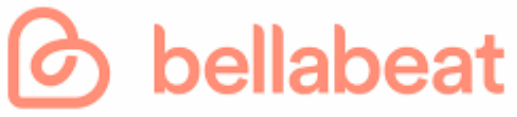

# <span style="color:#96AA80;">1. Introduction</span>

Bellabeat is a high-tech wellness company that manufactures health-focused smart products. Since it was founded in 2013, it has become a key wellness company for women around the world. Bellabeat wants to analyze smart device fitness data to help unlock new growth opportunities for the company. They want high-level recommendations for how trends in non-Bellabeat fitness device data can inform Bellabeat marketing strategy. 

In this case study, I will be analyzing Fitbit data to find trends in how users are using their smart health devices and create recommendations for the Bellabeat App. The Bellabeat App connects to their smart wellness products and provides users with health data related to their activity, sleep, stress, menstrual cycle, and mindfulness habits.

# <span style="color:#96AA80;">2. Ask Phase</span>

## <span style="color:#BE917C;">2.1 Business Task</span>

Analyze smart device usage data to find insights on how consumers use non-Bellabeat smart devices to improve Bellabeat’s marketing strategy.

## <span style="color:#BE917C;">2.2 Stakeholders</span>

Key stakeholders include:
* Urška Sršen - Chief Creative Officer and Bellabeat’s cofounder
* Sando Mur - Mathematician and Bellabeat’s cofounder
* Bellabeat’s marketing analysis team

# <span style="color:#96AA80;">3. Prepare Phase</span>

## <span style="color:#BE917C;">3.1 Dataset information</span>

I will be using the “FitBit Fitness Tracker Data” by Möbius on Kaggle, which is licensed under the CCO Public Domain, meaning it's free for the public to use without permission. The dataset was created by respondents to a distributed survey via Amazon Mechanical Turk between 03/12/2016 and 05/12/2016.

## <span style="color:#BE917C;">3.2 Data organization</span>

The datasets are organized into two folders: **Fitabase Data 3.12.16-4.11.16** and **Fitabase Data 4.12.16-5.12.16**. The first folder has 11 datasets with data from 03/12/2016 to 04/11/2016 and the second has 18 from 04/12/2016 to 5/12/2016. The data is in long format and each ID is found in multiple rows with different dates. The datasets are separated into 2 files for each month and found in each folder with the same name. There are also different files of the same data seperated into minute, hourly, and daily data.


## <span style="color:#BE917C;">3.3 Data credibility and integrity</span>

Since the data is from 2016, it is outdated. Furthermore, when inspecting and cleaning the data I found that multiple days of data were missing for most of the participants. Furthermore, the description of the dataset claims there were 30 participants, however when looking through the files I found as many as 35 unique IDs. The sample size is also very small, which can introduce bias if these individuals were chosen from similar backgrounds or areas, which we have no information about. Taking into consideration all of these facts, I conclude that this dataset does not pass the integrity and credibility test.

## <span style="color:#BE917C;">3.4 Datasets I will be using</span>

Some datasets are separated into 2 files for each month and are found in both **Fitabase Data 3.12.16-4.11.16** and **Fitabase Data 4.12.16-5.12.16** folders. I will be using 9 datasets. The datasets I will be using are listed and described below:

* **dailyActivity_merged** (for both months): Daily number of steps, distance, intensities, calories over 2 months for 34 users
* **hourlySteps_merged** (for both months): Hourly number of steps over 2 months for 34 users
* **hourlyCalories_merged** (for both months): Hourly calories over 2 months for 34 users
* **hourlyIntesities_merged** (for both months): Hourly intensities over 2 months for 34 users
* **sleepDay_merged** (only available for April **[4.12.16-5.12.16]**): Daily sleep records, minutes asleep, and minutes in bed iin the month of April for 25 users

## <span style="color:#BE917C;">3.5 Datasets I will not be using</span>

I also wanted to mention why I won't be using some of the other datasets:

* I will not be using **weightLogInfo_merged** because there are only 8 unique IDs in the dataset and **heartrate_sconds_merged** because there are only 13.
* I will not be using **minuteSleep_merged** because the data is stored in a column called “value” and it is not clear what “value” is in this context.
* I will not be using **minuteMETsNarrow_merged** because after some research I found out that 1 MET is the equivalent to the energy used while sitting still and more than 6 METs being vigorous activity, and after seeing most of the activity being sedentary in the dailyActivity_merged, there should be more entries closer to 1. However, there were no entries like this and most of the entries were closer to 10, which did not align with my research.
* I will not be using **dailycalories_merged**, **dailyIntensities_merged**, **dailysteps_merged** because that information is already in dailyActivity_merged


# <span style="color:#96AA80;">4. Process Phase</span>

## <span style="color:#BE917C;">4.1 Cleaning in Excel</span>

To clean the data I used Excel. First, I used conditional formatting to check for blanks and duplicates based on both the ID and date column. I did not find any blanks or duplicates.

I checked the number of days recorded for each ID and found that all the IDs have different amounts of days of data recorded, and very few had data for all the days. I also checked the amount of unique IDs and found some exceed the claimed 30 participants, as stated before.

## <span style="color:#BE917C;">4.2 Merging and cleaning in Python</span>

Then, I moved to Python and used **pandas** to combine both of the **dailyActivity_merged** files to make **daily_merged** for the entire time period of the survey. I also used pandas to add a Day of the Week column, which will be used in the analysis. 

I realized that the two separate datasets each had 4/12/2016 entries for some users so when the two months were merged there were duplicate values, so I dropped one copy in Python.

In [43]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import sqlite3 # to export pandas dataframes to a sql database

# --- load and merge daily activities
daily_march = pd.read_csv(
    "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/dailyActivity_merged.csv"
)
daily_april = pd.read_csv(
    "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv"
)
daily_merged = pd.concat([daily_march, daily_april], axis=0).round(2)

# --- drop extra 4/12/2016 entires
daily_merged = daily_merged.drop_duplicates(subset=["Id", "ActivityDate"], keep="last")

# --- fix the type of ActivityDate to datetime and add day of the week column
daily_merged["ActivityDate"] = pd.to_datetime(daily_merged["ActivityDate"], format="%m/%d/%Y")
daily_merged.insert(2, "DayOfTheWeek", daily_merged["ActivityDate"].dt.day_name())

Then, I merged each of the 3 hourly datasets (steps, calories, intensities) for both months to create hourly activity datasets for both months. Then, I combined the hourly activities for both months to make **hourly_merged**. I also dropped duplicates and fixed the ActivityHour column to be in **datetime** type.

In [44]:
# --- load and merge hourly activities
hourly_cal_march = pd.read_csv(
    "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv"
)
hourly_int_march = pd.read_csv(
    "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv"
)
hourly_steps_march = pd.read_csv(
    "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlySteps_merged.csv"
)
hourly_cal_april = pd.read_csv(
    "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv"
)
hourly_int_april = pd.read_csv(
    "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlyIntensities_merged.csv"
)
hourly_steps_april = pd.read_csv(
    "/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv"
)

# --- merge each month's using inner join
hourly_march = pd.merge(hourly_cal_march, hourly_int_march, on=["Id", "ActivityHour"], how="inner")
hourly_march = pd.merge(hourly_march, hourly_steps_march, on=["Id", "ActivityHour"], how="inner")

hourly_april = pd.merge(hourly_cal_april, hourly_int_april, on=["Id", "ActivityHour"], how="inner")
hourly_april = pd.merge(hourly_april, hourly_steps_april, on=["Id", "ActivityHour"], how="inner")

# --- vertically merge both months together and drop duplicates
hourly_merged = pd.concat([hourly_march, hourly_april], axis=0).round(2)
hourly_merged = hourly_merged.drop_duplicates(subset=["Id", "ActivityHour"], keep="last")

# --- fix ActivityHour to datetime type and add day of week and seperate hour column in 12-hour format to use in analysis
hourly_merged["ActivityHour"] = pd.to_datetime(hourly_merged["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p")
hourly_merged["DayOfTheWeek"] = hourly_merged["ActivityHour"].dt.day_name()
hourly_merged["Hour12"] = hourly_merged["ActivityHour"].dt.strftime("%I %p")

I also fixed the SleepDay column of **sleepDay_merged** to datetime and dropped duplicates just in case.

In [45]:
# --- clean sleepDay, fix SleepDay column to be datetime

sleep_day = pd.read_csv("/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")
sleep_day["SleepDay"] = pd.to_datetime(sleep_day["SleepDay"], format="%m/%d/%Y %I:%M:%S %p")
sleep_day = sleep_day.drop_duplicates(subset=["Id", "SleepDay"], keep="last")

The DataFrames I will be using from now on are **daily_merged**, **hourly_merged**, and **sleep_day**.

## <span style="color:#BE917C;">4.3 Export to SQL database</span>

Initially, I tried to export these DataFrames to CSV files and import them into PostgreSQL to analyze with SQL. However, it was giving me errors during the import process, so I decided to export the pandas DataFrames to an SQL database directly from Python. 

For this notebook, the database will be created and queried within the Kaggle environment using **SQLite** rather than PostgreSQL.

In [46]:
# --- export daily_activity, hourly_activity, sleep_day to sql database for further analysis

conn = sqlite3.connect("/kaggle/working/fitbit.db")
daily_merged.to_sql("daily_activity", conn, if_exists="replace", index=False)
hourly_merged.to_sql("hourly_activity", conn, if_exists="replace", index=False)
sleep_day.to_sql("sleep_day", conn, if_exists="replace", index=False)

410

# <span style="color:#96AA80;">5. Analyze Phase</span>

## <span style="color:#BE917C;">5.1 Daily averages in Python</span>

First, still in the Python environment, I used  pandas to get an overview of the daily data. I merged the daily activity and sleep data, using outer join to include all the data, and used the pandas **describe()** method to get summary statistics of daily steps, minutes of different intensities, sedentary minutes, calories, and minutes asleep.

In [47]:
# --- analysis: Take daily average, min, max 

# merge daily_activity and sleep_day to get both activity and sleep stats
daily_sleep_merged = pd.merge(daily_merged, sleep_day, left_on=["Id", "ActivityDate"], right_on=["Id", "SleepDay"], how="outer")

# convert sedentary and sleep minutes to hours because the value are large enough to be better understood as hours
daily_sleep_merged["HoursAsleep"] = round(daily_sleep_merged["TotalMinutesAsleep"]/60, 2)
daily_sleep_merged["SedentaryHours"] = round(daily_sleep_merged["SedentaryMinutes"]/60, 2)

# summarize minutes of activity minutes into minutes of moderate activity
daily_sleep_merged["ExerciseMinutes"] = daily_sleep_merged["FairlyActiveMinutes"] + (2 * daily_sleep_merged["VeryActiveMinutes"])

# find min, max, and avg using describe()
daily_stats = daily_sleep_merged.describe().loc[["mean","min","max"], ["TotalSteps", "VeryActiveMinutes", "FairlyActiveMinutes", "LightlyActiveMinutes", "ExerciseMinutes", "SedentaryHours", "Calories", "HoursAsleep"]].round(2)
daily_stats

,TotalSteps,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,ExerciseMinutes,SedentaryHours,Calories,HoursAsleep
mean,7377.38,19.87,13.6,188.1,53.35,16.69,2294.81,6.99
min,0.00,0.00,0.0,0.0,0.00,0.00,0.00,0.97
max,36019.00,210.00,660.0,720.0,660.00,24.00,4900.00,13.27


**Exercise:** According to this article, [https://www.cdc.gov/physical-activity-basics/guidelines/adults.html](https://www.cdc.gov/physical-activity-basics/guidelines/adults.html), 150 minutes of moderate activity or 75 minutes of vigorous activity is recommended in a week for adults or a combination of both, meaning vigorous activity is worth twice as much as moderate activity. Using this information, I summarized fairly and very active minutes into a metric that represents total moderately equivalent minutes of physical activity as an "ExerciseMinutes" column. The average of 53.4 minutes is more than the 21.4 (150 weekly/7 days) recommended daily.

**Sleep:** It appears on average, the Fitbit users are just in the recommended 7 to 9 hours of sleep range with 7 hours (rounded) of sleep, which is slightly more than the 6.8 hours of sleep the average person gets. Data for recommended and average sleep come from this article: [https://www.singlecare.com/blog/news/sleep-statistics/]https://www.singlecare.com/blog/news/sleep-statistics/).

**Steps:** The average steps is almost within the range of 8000 to 10000 recommended daily steps, with 7377 steps daily. That's more than the average in the U.S., which is 4,000 to 5,000 (considered a sedentary lifestyle). Data for recommended and average daily steps come from this article: [https://www.uclahealth.org/news/article/how-many-steps-do-you-need-day-see-health-benefits](https://www.uclahealth.org/news/article/how-many-steps-do-you-need-day-see-health-benefits)

This shows that fitness smart device users most likely care about their health and are more active than the average person, which makes sense since they own a device that tracks their health.

**Sedentary Activity:** However, an average of 16.7 hours of sedentary activity is more than the recommended limit of 10.6 hours per day mentioned in this article: [https://www.massgeneralbrigham.org/en/about/newsroom/articles/sedentary-time-cardiovascular-health](https://www.massgeneralbrigham.org/en/about/newsroom/articles/sedentary-time-cardiovascular-health).


## <span style="color:#BE917C;">5.2 Individual averages in SQL</span>

For the rest of the notebook, I will be using SQL. The SQL tables I will be using are **daily_activity**, **hourly_activity**, and **sleep_day**. The last table only has data for April.

I wanted to check individual averages to see if there were any trends in their activities. I decided to sort by number of steps and compare other metrics against that.

In [48]:
query = '''
SELECT da."Id",
	ROUND(AVG(da."TotalSteps"), 2) as "Avg Steps",
	ROUND(AVG(da."VeryActiveMinutes"), 2) as "Avg Very Active Mins",
	ROUND(AVG(da."FairlyActiveMinutes"), 2) as "Avg Fairly Active Mins",
	ROUND(AVG(da."LightlyActiveMinutes"), 2) as "Avg Lightly Active Mins",
    ROUND(AVG(da."FairlyActiveMinutes" + 2*da."VeryActiveMinutes"), 2) as "Avg Exercise Mins",
	ROUND(AVG(da."SedentaryMinutes"), 2) as "Sedentary Mins",
	ROUND(AVG(da."Calories"), 2) as "Avg Calories",
	ROUND(AVG(sd."TotalMinutesAsleep"), 2) as "Avg Mins Asleep"
FROM daily_activity as da
INNER JOIN sleep_day as sd
	ON da."Id" = sd."Id" 
	AND da."ActivityDate" = sd."SleepDay"
GROUP BY da."Id"
ORDER BY "Avg Steps" DESC
'''
pd.read_sql_query(query, conn)

,Id,Avg Steps,Avg Very Active Mins,Avg Fairly Active Mins,Avg Lightly Active Mins,Avg Exercise Mins,Sedentary Mins,Avg Calories,Avg Mins Asleep
0,8053475328,19078.67,111.67,13.00,176.33,236.33,837.33,3309.33,297.00
1,1503960366,12405.68,37.92,20.28,233.12,96.12,759.28,1872.28,360.28
2,3977333714,11218.00,19.82,61.29,181.54,100.93,716.21,1560.39,293.64
3,4388161847,11034.35,27.48,20.52,240.35,75.48,745.17,3141.74,400.17
4,7086361926,10290.50,47.46,27.58,158.96,122.50,723.67,2657.63,453.13
5,6962181067,9794.81,22.81,18.52,245.81,64.13,662.32,1982.03,448.00
6,5577150313,9260.08,97.88,33.38,164.96,229.15,667.31,3539.19,432.00
7,4702921684,9035.85,5.37,23.78,255.67,34.52,697.33,3019.56,417.48
8,6117666160,8823.83,2.44,2.44,359.67,7.33,531.94,2460.83,478.78
9,8378563200,8717.71,58.68,10.26,156.10,127.61,716.13,3436.58,445.13


It appears in most cases, the more steps an individual takes the more minutes they are "Very Active". It also appears that number of steps don't have any obvious direct relation with number of calories burned, probably as a result of different body masses, eating habits, and fitness activities that don't involve steps. 

I also noticed average sleep time don't seem to relate to steps, so I wanted to see what does affect sleep time. I ran the query again, but this time sorting by average sleep time.

In [49]:
query = '''
SELECT da."Id",
	ROUND(AVG(da."TotalSteps"), 2) as "Avg Steps",
	ROUND(AVG(da."VeryActiveMinutes"), 2) as "Avg Very Active Mins",
	ROUND(AVG(da."FairlyActiveMinutes"), 2) as "Avg Fairly Active Mins",
	ROUND(AVG(da."LightlyActiveMinutes"), 2) as "Avg Lightly Active Mins",
    ROUND(AVG(da."FairlyActiveMinutes" + 2*da."VeryActiveMinutes"), 2) as "Avg Exercise Mins",
	ROUND(AVG(da."SedentaryMinutes"), 2) as "Sedentary Mins",
	ROUND(AVG(da."Calories"), 2) as "Avg Calories",
	ROUND(AVG(sd."TotalMinutesAsleep"), 2) as "Avg Mins Asleep"
FROM daily_activity as da
INNER JOIN sleep_day as sd
	ON da."Id" = sd."Id" 
	AND da."ActivityDate" = sd."SleepDay"
GROUP BY da."Id"
ORDER BY "Avg Mins Asleep" DESC
'''
pd.read_sql_query(query, conn)

,Id,Avg Steps,Avg Very Active Mins,Avg Fairly Active Mins,Avg Lightly Active Mins,Avg Exercise Mins,Sedentary Mins,Avg Calories,Avg Mins Asleep
0,1844505072,3477.00,0.00,2.33,145.00,2.33,443.33,1676.33,652.00
1,2026352035,5618.68,0.11,0.29,256.50,0.50,653.96,1540.79,506.18
2,6117666160,8823.83,2.44,2.44,359.67,7.33,531.94,2460.83,478.78
3,4319703577,7125.42,2.62,12.31,244.31,17.54,642.69,2024.69,476.65
4,5553957443,8612.58,23.42,13.00,206.19,59.84,668.35,1875.68,463.48
5,7086361926,10290.50,47.46,27.58,158.96,122.50,723.67,2657.63,453.13
6,6962181067,9794.81,22.81,18.52,245.81,64.13,662.32,1982.03,448.00
7,2347167796,8533.20,9.20,16.13,245.87,34.53,628.40,1971.33,446.80
8,8378563200,8717.71,58.68,10.26,156.10,127.61,716.13,3436.58,445.13
9,8792009665,3443.27,1.67,7.27,169.47,10.60,807.80,2299.33,435.67


From the table, average time asleep is very closely aligned to average sedentary minutes, which is the minutes a person is awake without doing any physical activity. Participants who slept more generally also tended to have fewer sedentary minutes.

I did take into consideration this can be due to the fact that individuals who sleep less simply have more waking hours available, resulting in more time that can be spent either sedentary or active. However, a similar pattern is not observed in the other activity categories (lightly active, fairly active, or very active minutes). This suggests that sleep duration may be more closely related to sedentary behavior than to overall activity levels within this dataset. To get more context, I did a little research and found that prior studies show an association between sedentary behavior and sleep outcomes and that sedentary activity disrupts sleep by reducing the body's physical need to rest, which is said in this article: [https://pmc.ncbi.nlm.nih.gov/articles/PMC12186656/](https://pmc.ncbi.nlm.nih.gov/articles/PMC12186656/).

## <span style="color:#BE917C;">5.3 Relationship between sleep and sedentary activity</span>

I ran another query that focuses on sedentary time and sleep time.

In [63]:
query = '''
SELECT da."Id", da."ActivityDate", 
ROUND(da."SedentaryMinutes"/60.0, 2) AS "Sedentary Hours", 
da."FairlyActiveMinutes" + 2*da."VeryActiveMinutes" AS "Exercise Mins",
ROUND(sd."TotalMinutesAsleep"/60.0, 2) AS "Total Hours Asleep"
FROM daily_activity AS da
INNER JOIN sleep_day AS sd
	ON da."Id" = sd."Id"
	AND da."ActivityDate" = sd."SleepDay"
ORDER BY da."SedentaryMinutes" DESC
'''
pd.read_sql_query(query, conn)

,Id,ActivityDate,Sedentary Hours,Exercise Mins,Total Hours Asleep
0,4319703577,2016-04-21 00:00:00,21.08,0,0.98
1,4020332650,2016-04-16 00:00:00,20.37,151,1.28
2,4445114986,2016-04-17 00:00:00,20.32,0,1.63
3,1644430081,2016-04-29 00:00:00,19.88,0,1.98
4,1927972279,2016-04-28 00:00:00,19.45,0,2.77
...,...,...,...,...,...
405,1844505072,2016-04-30 00:00:00,3.63,0,12.03
406,6962181067,2016-05-12 00:00:00,2.12,8,8.60
407,6117666160,2016-05-09 00:00:00,2.08,0,8.20
408,2347167796,2016-04-29 00:00:00,0.03,0,6.85


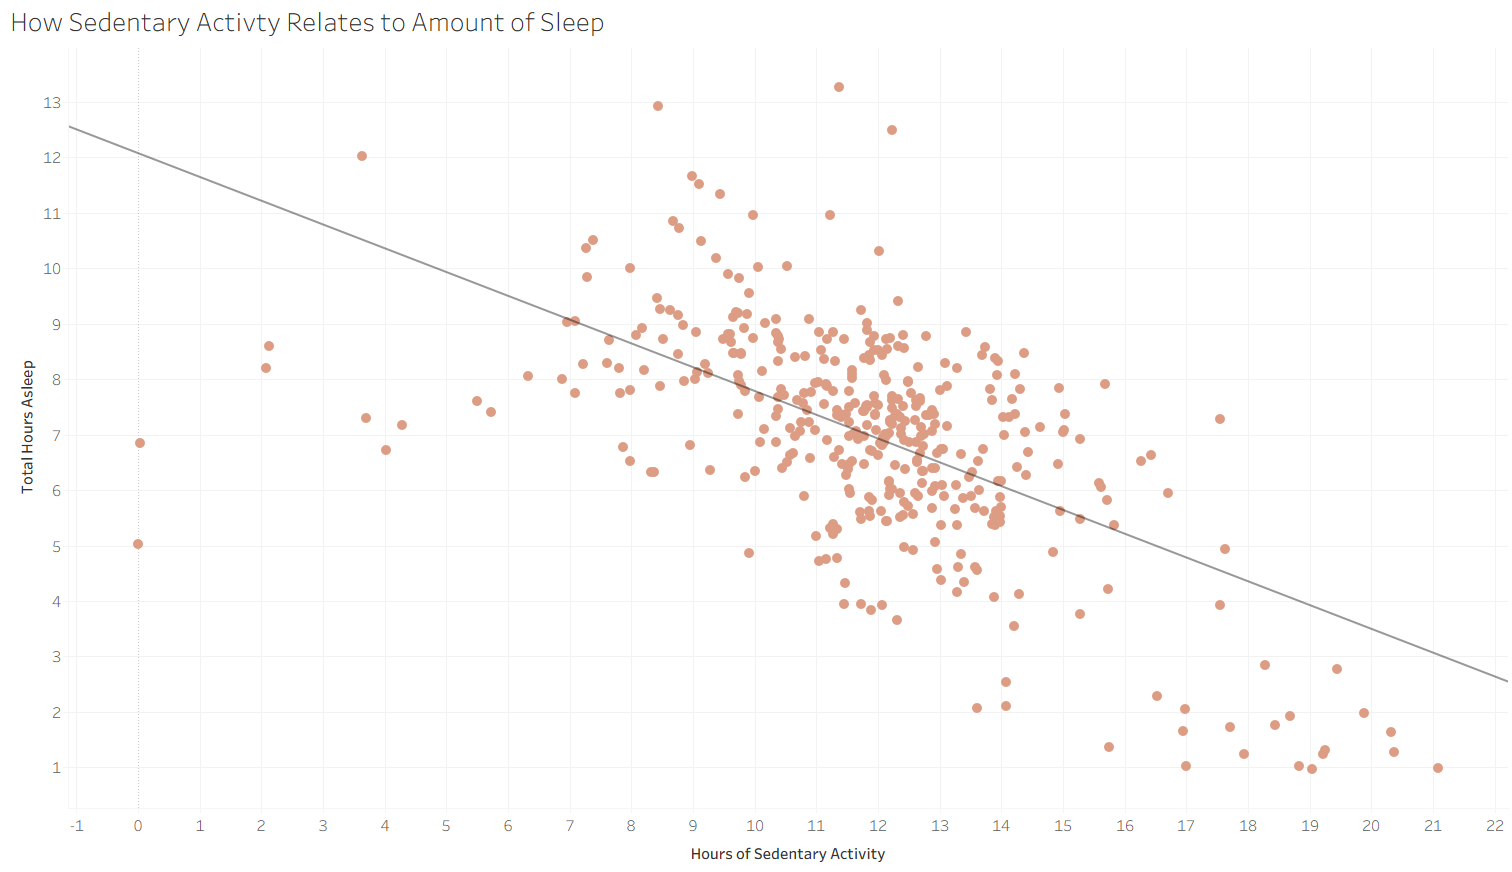

In [61]:
# --- Correlation coefficient 

print(daily_sleep_merged["SedentaryHours"].corr(daily_sleep_merged["HoursAsleep"]))

-0.6011086899616221


Instead of averages for every ID, I checked the raw hours every day for every ID. I found the pattern still held on a daily level. As shown on the scatterplot, there is a downward trend line, showing that on days someone had more sedentary hours, they had less hours of sleep on average.

I also found a moderate negative correlation of -0.60 in Python, suggesting users who spend more time sedentary tend to sleep less.

## <span style="color:#BE917C;">5.4 Classifying users by activity</span>

Next I wanted to see how many of the users were getting the recommended 150 minutes of moderate physical activity a week on average. 

To determine whether participants met recommended activity levels, I calculated a daily moderate-equivalent activity score using the Fitbit activity categories. Fairly active minutes were counted at their full value, while very active minutes were weighted twice as heavily. This weighting is based on physical activity guidelines, which generally consider one minute of vigorous activity to be equivalent to two minutes of moderate activity.

The resulting calculation was:
**Moderate-Equivalent Minutes = Fairly Active Minutes + (2 × Very Active Minutes)**

Public health guidelines recommend at least 150 minutes of moderate-intensity activity per week, or an equivalent combination of moderate and vigorous activity. To compare the Fitbit data to this recommendation, I converted the weekly target into a daily average:
**150 minutes ÷ 7 days = 21.4 minutes per day**

Participants with an average of at least 21.4 moderate-equivalent minutes per day were classified as meeting the recommended activity level, while those below this threshold were classified as not meeting the recommendation.

In [51]:
query = '''
SELECT "Meets Recommended Exercise?",
    COUNT("Id") AS "Number of IDs"
FROM (
    SELECT "Id",
    	CASE
            WHEN AVG("FairlyActiveMinutes" + 2*"VeryActiveMinutes") >= 21.4 THEN 'Enough Exercise'
            WHEN AVG("FairlyActiveMinutes" + 2*"VeryActiveMinutes") < 21.4 THEN 'Not Enough Exercise'
        END AS "Meets Recommended Exercise?"
    FROM daily_activity 
    GROUP BY "Id"
)
GROUP BY "Meets Recommended Exercise?"
'''
pd.read_sql_query(query, conn)

,Meets Recommended Exercise?,Number of IDs
0,Enough Exercise,23
1,Not Enough Exercise,12


It appears more than half of the participants were getting enough exercise. I wanted to break this down further, while using another metric: steps.

Using the classifications in this article [https://pmc.ncbi.nlm.nih.gov/articles/PMC3197470/](https://pmc.ncbi.nlm.nih.gov/articles/PMC3197470/) , I classified users into 5 categories based on their daily steps:
1) **Sedentary:** < 5,000 steps/day 
2) **Low Active:** 5,000-7,499 steps/day 
3) **Somewhat Active:** 7,500-9,999 steps/day 
4) **Active:** 10,000-12,499 steps/day 
5) **Highly Active:** ≥12,500 steps/day 


In [52]:
query = '''
SELECT "Level of Activity",
COUNT("Id") as "Number of Ids"
FROM (
	SELECT "Id", 
	ROUND(AVG("TotalSteps"), 2) AS "Avg Steps",
	CASE
		WHEN AVG("TotalSteps") < 5000 THEN 'Sedentary'
		WHEN AVG("TotalSteps") BETWEEN 5000 AND 7499 THEN 'Low Active'
		WHEN AVG("TotalSteps") BETWEEN 7500 AND 9999 THEN 'Somewhat Active'
		WHEN AVG("TotalSteps") BETWEEN 10000 AND 12499 THEN 'Active'
		WHEN AVG("TotalSteps") > 12500 THEN 'Highly Active'
	END AS "Level of Activity"
	FROM daily_activity
	GROUP BY "Id"
	) 
GROUP BY "Level of Activity"
ORDER BY "Number of IDs" DESC
'''
pd.read_sql_query(query, conn)

,Level of Activity,Number of Ids
0,Sedentary,11
1,Low Active,9
2,Somewhat Active,8
3,Active,5
4,Highly Active,2


The largest category was sedentary, which is also the average in the U.S according to my research. Most of the users turned out to in the low-active to somewhat-active range. This indicates that the average smart fitness device users are probably ordinary people, not athletes or in the top percent.

## <span style="color:#BE917C;">5.5 Activity by day of the week</span>

Next I wanted to see the average activity throughout the week and possibly identify days with the most/least activity or sleep. I will use the DayOfTheWeek column I made with pandas for simplicity since SQLite doesn't have a function that directly extracts the name of the weekday.

In [53]:
query = '''
SELECT da."DayOfTheWeek" as "Day of the Week",
	ROUND(AVG("TotalSteps"), 2) as "Avg Steps",
    ROUND(AVG("Intensity"), 2) as "Avg Intensity",
	ROUND(CAST(AVG("TotalDistance") AS Numeric), 2) as "Avg Distance",
	ROUND(AVG("VeryActiveMinutes"), 2) as "Avg Very Active Mins",
	ROUND(AVG("FairlyActiveMinutes"), 2) as "Avg Fairly Active Mins",
	ROUND(AVG("LightlyActiveMinutes"), 2) as "Avg Lightly Active Mins",
    ROUND(AVG("FairlyActiveMinutes" + 2*"VeryActiveMinutes"), 2) as "Avg Exercise Mins",
	ROUND(AVG("SedentaryMinutes"), 2) as "Sedentary Mins",
	ROUND(AVG(da."Calories"), 2) as "Avg Calories",
	ROUND(AVG(sd."TotalMinutesAsleep")/60, 2) as "Avg Hours Asleep"
FROM daily_activity as da
LEFT JOIN sleep_day as sd
	ON da."Id" = sd."Id" 
	AND da."ActivityDate" = sd."SleepDay"
LEFT JOIN (
    SELECT "Id",
        datetime(DATE("ActivityHour")) as "ActivityDate",
        ROUND(AVG("TotalIntensity"), 2) as "Intensity"
    FROM hourly_activity
    GROUP BY
        "Id",
        DATE("ActivityHour")
    ) as ha
    ON da."Id" = ha."Id"
    AND da."ActivityDate" = ha."ActivityDate"
GROUP BY da."DayOfTheWeek"
ORDER BY 
	CASE da."DayOfTheWeek"
		WHEN 'Monday' THEN 1
		WHEN 'Tuesday' THEN 2
		WHEN 'Wednesday' THEN 3
		WHEN 'Thursday' THEN 4
		WHEN 'Friday' THEN 5
		WHEN 'Saturday' THEN 6
		WHEN 'Sunday' THEN 7
    END
'''
pd.read_sql_query(query, conn)

,Day of the Week,Avg Steps,Avg Intensity,Avg Distance,Avg Very Active Mins,Avg Fairly Active Mins,Avg Lightly Active Mins,Avg Exercise Mins,Sedentary Mins,Avg Calories,Avg Hours Asleep
0,Monday,7541.32,11.76,5.37,21.61,12.70,184.68,55.91,1029.72,2298.40,6.99
1,Tuesday,7718.96,12.18,5.53,21.09,13.82,194.74,56.01,1012.21,2338.88,6.74
2,Wednesday,7547.58,11.82,5.46,19.86,13.44,189.92,53.16,994.71,2320.76,7.24
3,Thursday,7268.30,11.51,5.20,18.92,12.58,180.95,50.43,984.90,2223.75,6.69
4,Friday,7187.53,11.64,5.14,18.57,15.82,194.67,52.95,1020.27,2325.10,6.76
5,Saturday,7752.27,12.33,5.54,20.81,14.22,200.69,55.83,968.93,2325.80,6.98
6,Sunday,6606.73,10.74,4.76,18.25,12.54,170.09,49.05,999.73,2227.41,7.55


Sunday seems to have the least activity overall and the most sleep. Saturday has the highest average steps and intensity, while Monday and Tuesday also show relatively high activity levels. The weekdays also seem to have more sedentary minutes than the weekends, possibly due to people having sedentary desk jobs during the weekdays. 

## <span style="color:#BE917C;">5.6 Activity by the hour</span>

Finally, I wanted to see what activity levels were like by the hour. For hourly data, we only have calories, intensity levels, and calories available. I will use the Hour12 column I made with pandas for simplicity since SQLite extracts hours in 24-hour format not 12-hour.

In [54]:
query = '''
SELECT 
	"Hour12" AS "Hour",
	ROUND(AVG("Calories"), 2) AS "Avg Calories", 
	ROUND(AVG("TotalIntensity"), 2) AS "Avg Intensity", 
	ROUND(AVG("StepTotal"), 2) AS "Avg Steps"
FROM 
	hourly_activity
GROUP BY 
	"Hour"
ORDER BY
    strftime('%H',"ActivityHour")
'''
pd.read_sql_query(query, conn)

,Hour,Avg Calories,Avg Intensity,Avg Steps
0,12 AM,72.17,2.28,43.36
1,01 AM,69.92,1.38,21.88
2,02 AM,68.65,0.90,13.69
3,03 AM,67.56,0.50,6.85
4,04 AM,68.01,0.60,11.11
5,05 AM,79.62,4.33,34.93
6,06 AM,83.83,6.61,148.24
7,07 AM,92.27,10.05,282.65
8,08 AM,100.61,13.66,395.84
9,09 AM,106.32,15.31,431.37


The highest activity intensity seems to be from 5PM to 7PM and that's also when the most calories are burned.

The most steps are 555 steps at 7PM. It appears most steps are taken between 9AM and 2PM and between 4PM and 7PM. That's around the time people go to work and people come home from work, respectively, which can be a possible cause of the steps. There also seems to be a drop in the middle at 3PM, when most people are already at work. To explore this further, I ran the same query two more times, one taking averages of only the weekdays and one taking averages of only the weekends. 

In [55]:
# --- Hourly averages on the weekdays

query = '''
SELECT 
	"Hour12" AS "Hour",
	ROUND(AVG("Calories"), 2) AS "Avg Weekday Calories", 
	ROUND(AVG("TotalIntensity"), 2) AS "Avg Weekday Intensity", 
	ROUND(AVG("StepTotal"), 2) AS "Avg Weekday Steps"
FROM 
	hourly_activity
WHERE
    strftime('%w', ActivityHour) != '0'
    AND strftime('%w', ActivityHour) != '6'
GROUP BY 
	"Hour"
ORDER BY
	strftime('%H', "ActivityHour")
'''
pd.read_sql_query(query, conn)

,Hour,Avg Weekday Calories,Avg Weekday Intensity,Avg Weekday Steps
0,12 AM,71.42,1.98,36.66
1,01 AM,69.30,1.13,18.20
2,02 AM,68.16,0.70,11.08
3,03 AM,67.46,0.45,6.30
4,04 AM,68.25,0.65,13.07
5,05 AM,84.36,5.77,43.27
6,06 AM,88.04,8.15,181.23
7,07 AM,95.27,11.10,322.11
8,08 AM,102.71,14.49,428.91
9,09 AM,105.90,15.18,436.51


On the weekdays, most steps seem to be taken between 8AM and 2PM and between 4PM and 7PM. The slightly different first interval better fits the time people go to work. The 3PM drop is also lower for only the weekdays (348 compared to 398). The most steps are taken during 6PM with 598 steps.

Highest activity intensity and calories burned still seems to be from 5PM to 7PM.

In [56]:
# --- Hourly averages on the weekends

query = '''
SELECT 
	"Hour12" AS "Hour",
	ROUND(AVG("Calories"), 2) AS "Avg Weekend Calories", 
	ROUND(AVG("TotalIntensity"), 2) AS "Avg Weekend Intensity", 
	ROUND(AVG("StepTotal"), 2) AS "Avg Weekend Steps"
FROM 
	hourly_activity
WHERE
    strftime('%w', ActivityHour) = '0'
    OR strftime('%w', ActivityHour) = '6'
GROUP BY 
	"Hour"
ORDER BY
	strftime('%H', "ActivityHour")
'''
pd.read_sql_query(query, conn)

,Hour,Avg Weekend Calories,Avg Weekend Intensity,Avg Weekend Steps
0,12 AM,74.00,3.02,59.65
1,01 AM,71.41,1.97,30.85
2,02 AM,69.85,1.36,20.07
3,03 AM,67.80,0.61,8.20
4,04 AM,67.42,0.50,6.33
5,05 AM,68.02,0.80,14.55
6,06 AM,73.56,2.86,67.74
7,07 AM,84.93,7.51,186.38
8,08 AM,95.49,11.65,315.13
9,09 AM,107.34,15.64,418.83


On the weekends, the times of the most steps are more evenly spread out from 10AM to 7PM. 10AM is closer to the time most people wake up and start moving on weekends compared to the 8AM in the weekday table. There's also no big drop at 3PM, indicating people aren't working. 

The highest steps is 601 steps at 2PM, which is a time most people are free on the weekend if they aren't working. Highest intensity and calories burned have shifted to earlier in the day to 12PM-3PM. These imply that most people probably aren't working desk jobs at this time and are free to move, which makes sense on the weekend.

# <span style="color:#96AA80;">6. Share Phase</span>

Now, I will share my key insights and use visualizations to illustrate them. My overall findings are:
* Most users are not getting the recommended 8,000-10,000 steps and fall within the sedentary to somewhat active categories
* Saturday is the day with most activity, with 7,752 steps and 12.33 intensity
* Sunday is the day with least activity, but the most sleep, indicating that it's a rest day
* There seems to be a negative relationship between hours of sleep and sedentary activity
* On weekdays, activity is affected by work schedule and most activity is from 5PM to 7PM
* On weekends, activity is more consistent throughout the day and higher from 12PM and 2PM

## <span style="color:#BE917C;">6.1 User classification by activity</span>

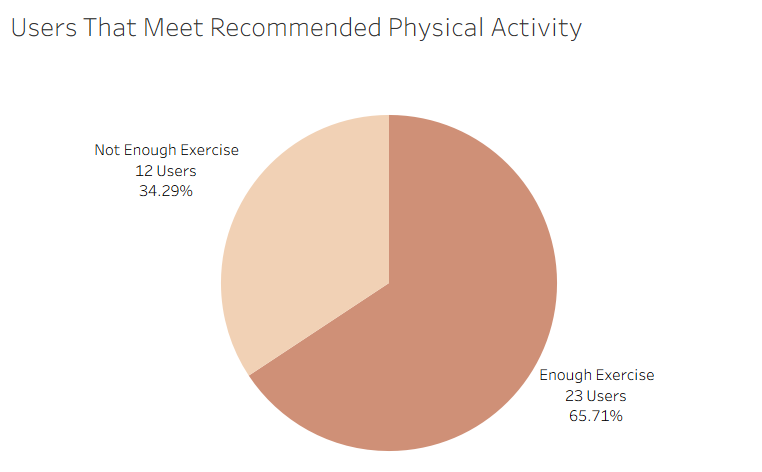

* Most of the participants are getting an average of 150 minutes of moderate activity weekly, but more than a third is still not getting enough

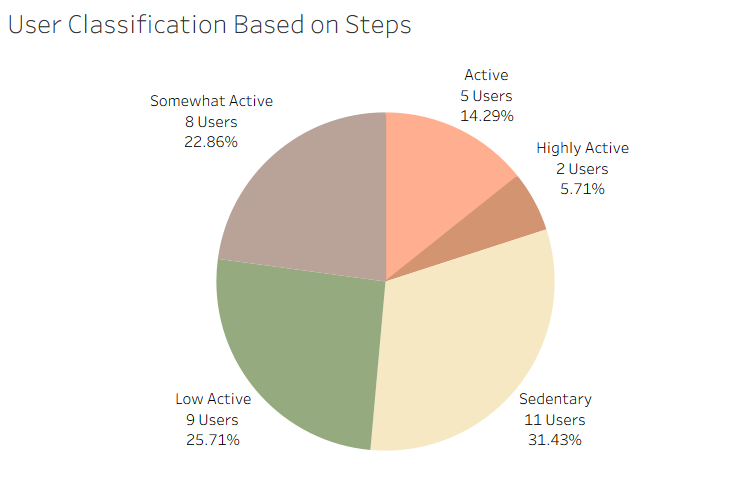

* The sedentary level for steps has the highest level of users with 31% 
* Most of the users fall into the sedentary to somewhat active levels when looking at average daily steps, meaning most users get less than the recommended 10,000 steps daily

## <span style="color:#BE917C;">6.2 Sleep throughout the week</span>

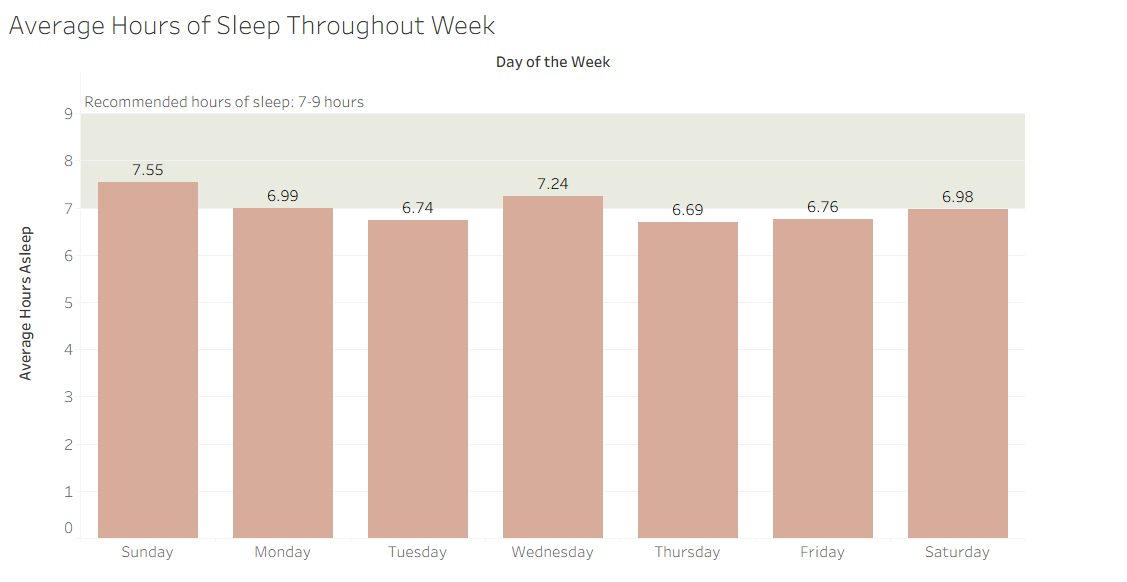
* Most days of the week have an average of about 7 hours of sleep, which is at the lower end of the recommended 7–9 hour range. Some days fall below the recommendation.
* Sunday has the most average hours of sleep at 7.5 hours

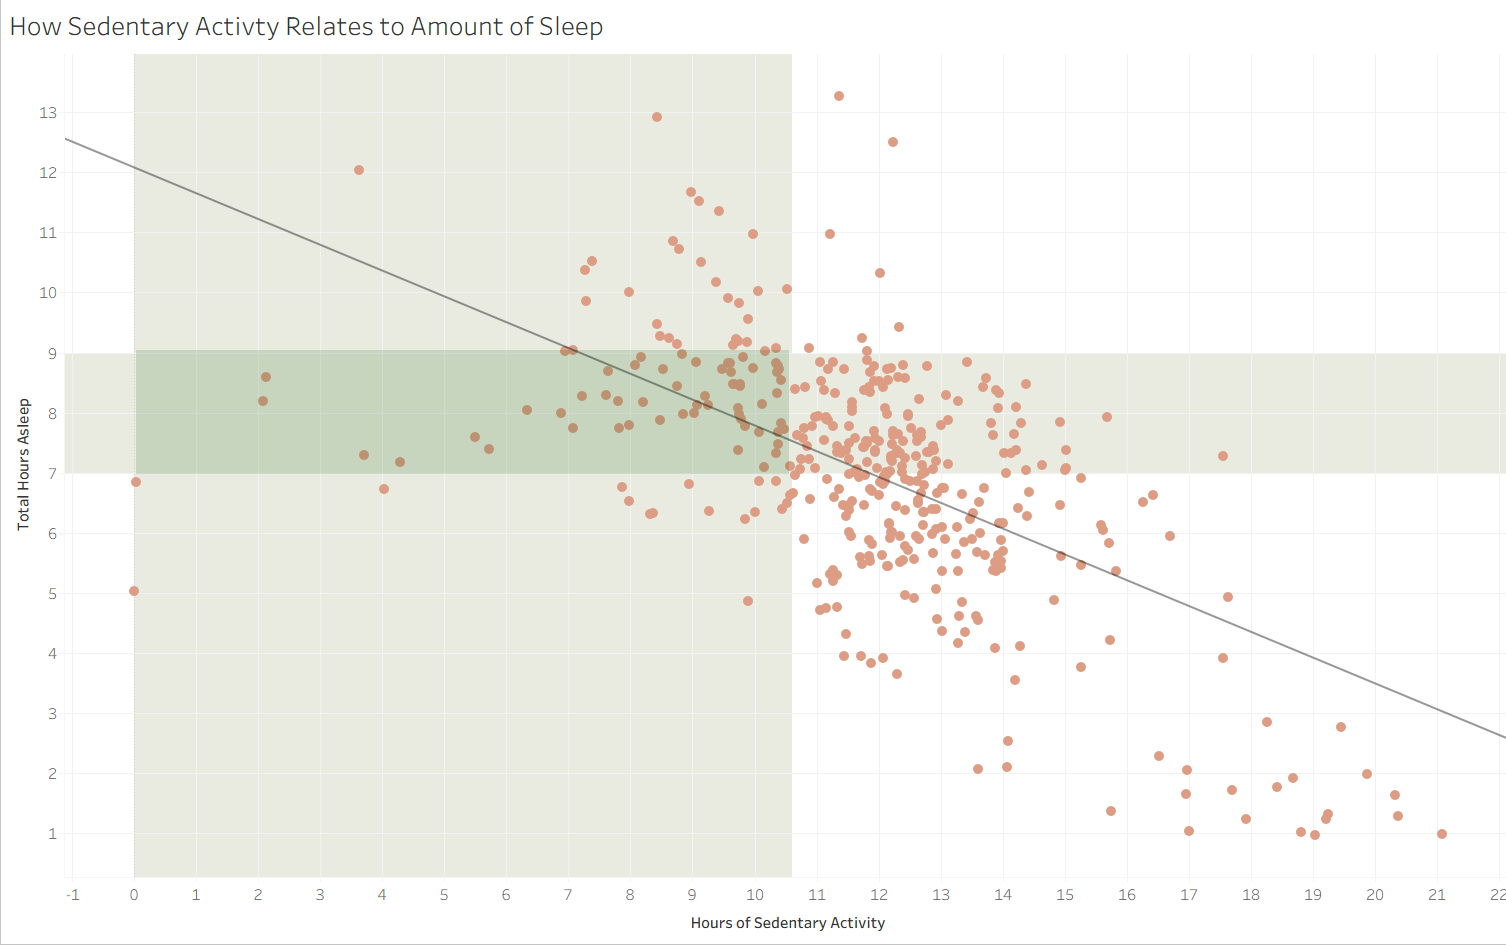
The graph shows the relationship between sedentary hours and sleep hours per day. There is a point for every daily record for each user. The green areas represent the recommended sleep range of 7–9 hours and sedentary activity limit of 10.6 hours per day. The intersection is the optimal area.
* The scatterplot shows a moderate negative correlation (r = -0.60) between sedentary hours and sleep duration. Users who spend more time sedentary tend to sleep fewer hours, although this relationship does not necessarily imply causation.

## <span style="color:#BE917C;">6.3 Times and days of most activity</span>

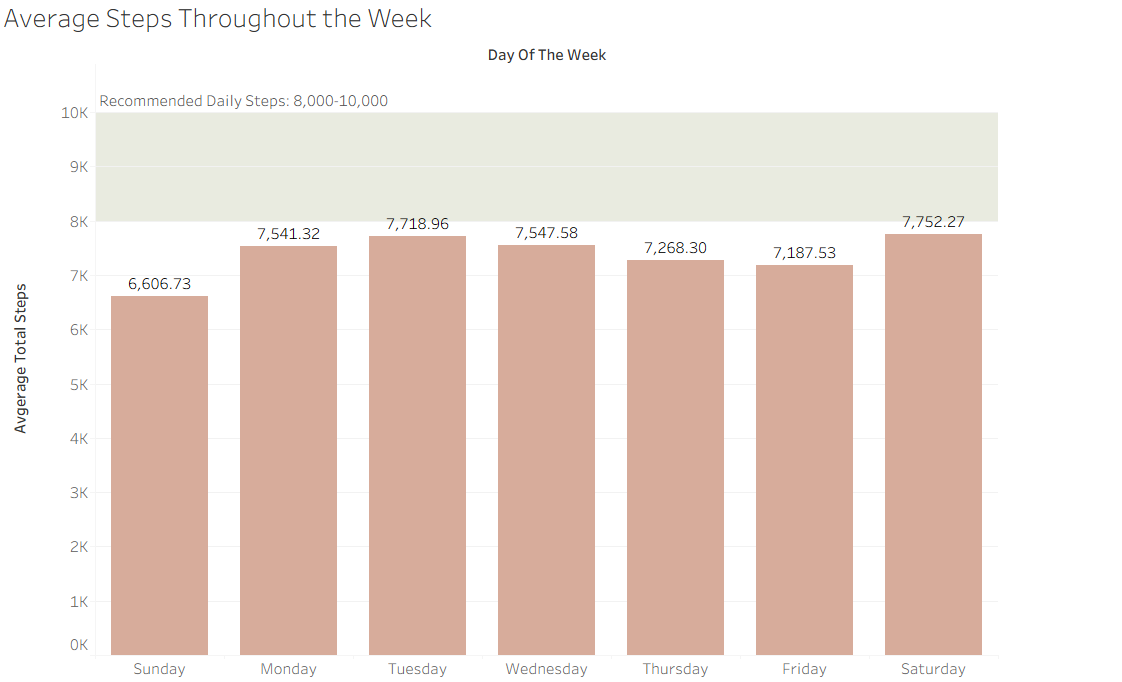
* The most steps are taken on Saturday with 7,752 steps on average
* Tuesday is a close second with 7,719 steps
* The least steps are taken on Sunday with 6,607 steps on average
* None of the days' average steps meet the recommended 8,000-10,000 steps

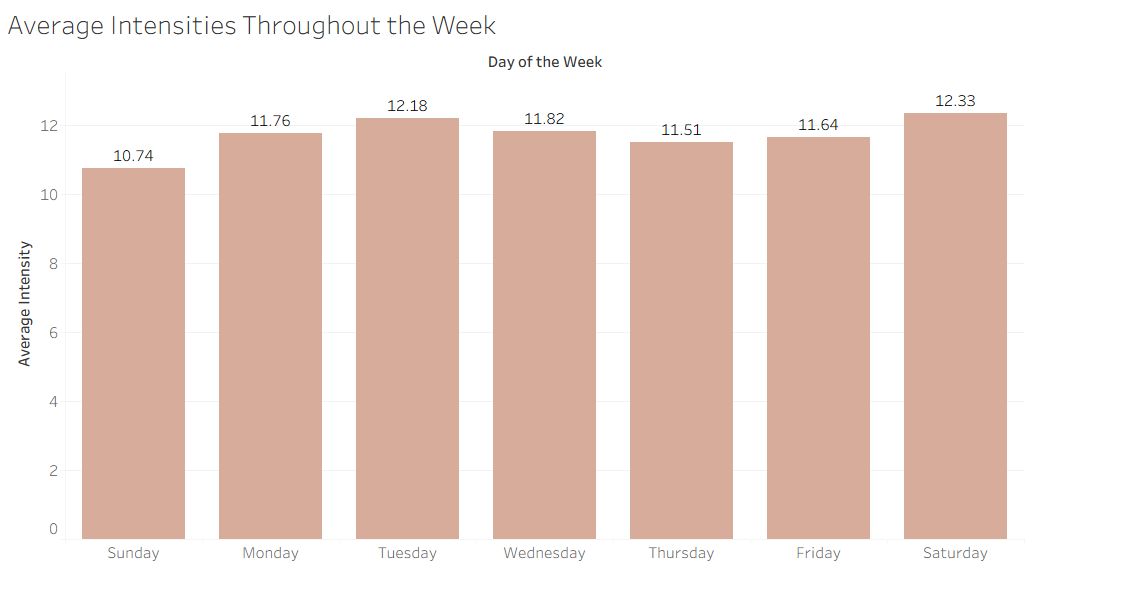
* The highest physical activity intensity is on Saturday with 12.33
* Tuesday is a close second with 12.18
* The lowest intensity is on Sunday with 10.74

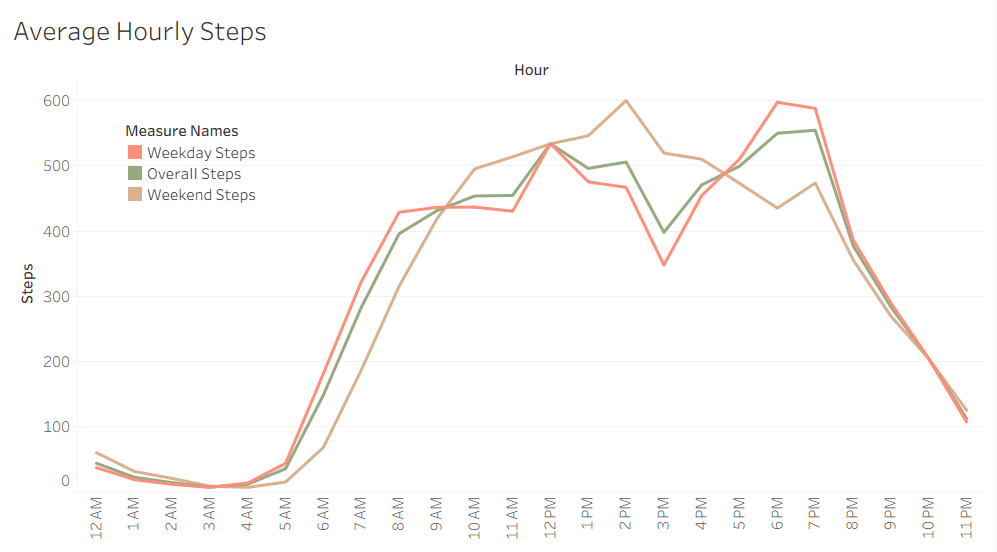
* On the weekends, the most steps are taken in the middle of the day between 12PM and 2PM
* On the weekdays, the most steps are taken at the end of the day between 5PM and 7PM
* On the weekdays, there is also a drop in steps at 3PM which is not present on the weekends
* On weekday mornings steps become steady at 7AM, indicating most people start moving at this time, most likely due to work
* On weekend mornings steps become steady at 10AM, indicating most people start moving at this time, probably waking up later due to being off from work on the weekends

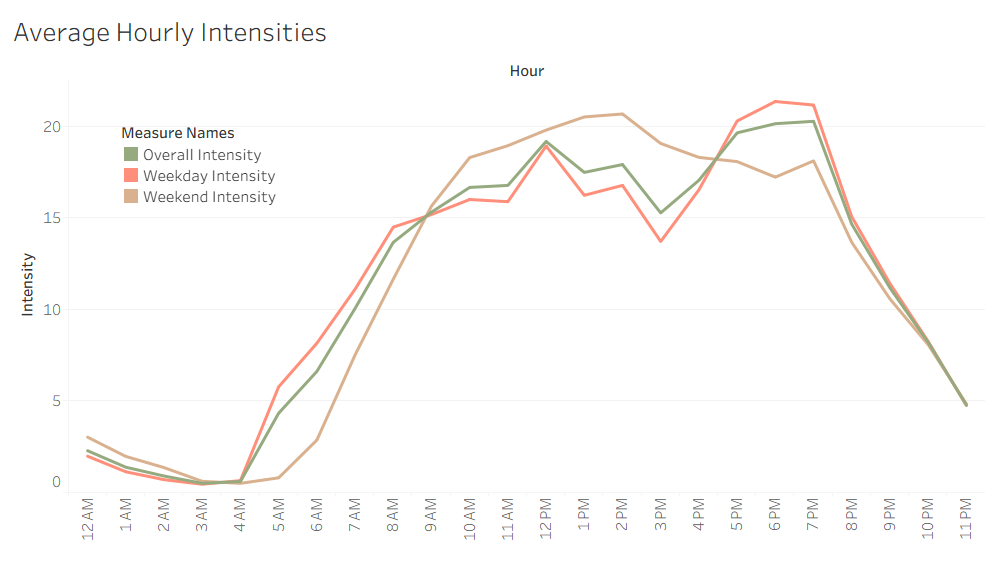
* On the weekends, activity intensity is more consistent throughout the day, with the most from 12PM to 2PM
* On the weekdays, activity intensity is most from 5PM to 7PM
* There is also a drop in intensity at 3PM on weekdays, like for steps
* Intensity also becomes steady at 7AM on weekdays and 10AM on weekends
* Intensity data is consistent with step data

# <span style="color:#96AA80;">7. Act Phase</span>

Finally, I will make some recommendations for Bellabeat marketing and the Bellabeat app based on my analysis. 

## <span style="color:#BE917C;">Recommendations</span>

1) The Bellabeat marketing team should focus marketing on everyday women instead of more active athletes, since that is the majority of smart fitness device users. Marketing should emphasize a woman's well-being and being healthy over being active, and everyday activities like cleaning and going to work should be acknowledged to encourage women.
2) The Bellabeat app should send motivating messages throughout the day and recommend workouts on Saturday noons and Tuesday evenings, since people are most active around these times. The Bellabeat app should send calming messages on Sunday and recommend relaxing activities like yoga to reduce stress from the week because Sunday seems to be a rest day.
3) Lastly, the Bellabeat app should give incentives for getting 8 hours of sleep and getting 8,000 steps a day. Incentives can be a streak count or points that can be used to unlock features in the app, customize the app, or can be applied to a discount for future Bellabeat purchases. The app should also encourage users to take a short walk after long periods of sedentary activity to improve sleep and help them meet the recommended daily step goals.